In [44]:
!pip install insightface

In [45]:
import insightface
import cv2

In [46]:
# Face Recognition
def face_detection(img):
    app = insightface.app.FaceAnalysis('buffalo_l')
    app.prepare(ctx_id=0)
    faces = app.get(img)
    return faces

In [48]:
import matplotlib.pyplot as plt

def plot_detection(faces, img):
  for i, face in enumerate(faces):
      box = face.bbox.astype(int)

      cv2.rectangle(
          img,
          (box[0], box[1]),
          (box[2], box[3]),
          (0, 255, 0),
          2
      )
      # Add text label for each face
      cv2.putText(
          img,
          f'Face {i}',
          (box[0], box[1] - 10),
          cv2.FONT_HERSHEY_SIMPLEX,
          0.9,
          (0, 255, 0),
          2
      )

  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  plt.figure(figsize=(8,8))
  plt.imshow(img_rgb)
  plt.axis("off")
  plt.show()

  print("number of faces founded: ",len(faces))

In [49]:
def to_embeddings(face):
  emb = face.embedding
  return emb

# TEST

In [50]:
original_img = cv2.imread("miror_img.jpg")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: [(128, 128), (640, 640)

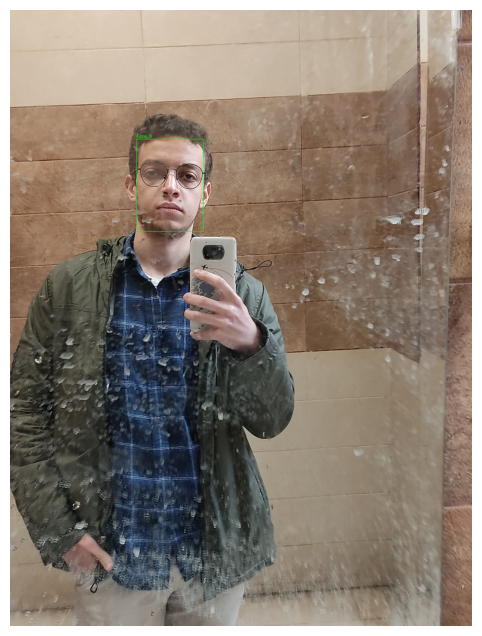

number of faces founded:  1


In [51]:
original_faces = face_detection(original_img)
plot_detection(original_faces, original_img)

In [52]:
my_face = original_faces[0]
org_emb = to_embeddings(my_face)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: [(128, 128), (640, 640)

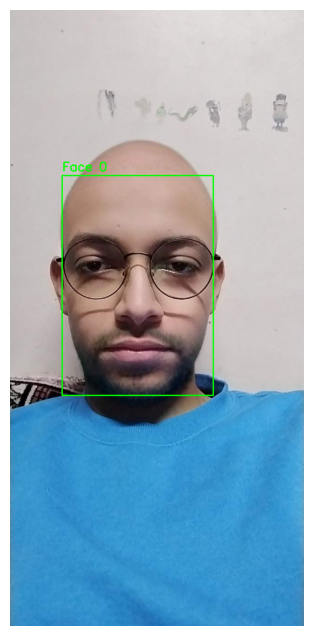

number of faces founded:  1


In [53]:
side_face = cv2.imread("bald.jpg")
side_face_detection = face_detection(side_face)
plot_detection(side_face_detection , side_face)

In [54]:
side_emb = to_embeddings(side_face_detection[0])

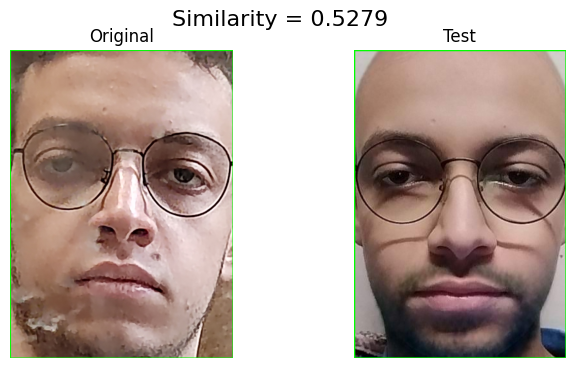

In [55]:
import numpy as np
similarity = np.dot(org_emb, side_emb) / (
    np.linalg.norm(org_emb) * np.linalg.norm(side_emb)
)

# قص الوش الأول
x1, y1, x2, y2 = my_face.bbox.astype(int)
crop1 = original_img[y1:y2, x1:x2]

# قص الوش الثاني
x1, y1, x2, y2 = side_face_detection[0].bbox.astype(int)
crop2 = side_face[y1:y2, x1:x2]

# OpenCV -> RGB
crop1 = cv2.cvtColor(crop1, cv2.COLOR_BGR2RGB)
crop2 = cv2.cvtColor(crop2, cv2.COLOR_BGR2RGB)

# العرض
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(crop1)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(crop2)
plt.title("Test")
plt.axis("off")

plt.suptitle(f"Similarity = {similarity:.4f}", fontsize=16)

plt.show()